# Classical Forecasting Models

## 1. Import Libraries

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_bitcoin_data
from src.preprocessing import prepare_daily_bitcoin_data
from src.metrics import mae, rmse, mape, smape

## 2. Load Dataset

In [2]:
data_path = PROJECT_ROOT / "data" / "bitcoin" / "btcusd_1-min_data.csv"

df_raw = load_bitcoin_data(data_path)
df_daily = prepare_daily_bitcoin_data(df_raw)
df_daily.head()

,Open,High,Low,Close,Volume
Timestamp,,,,,
2012-01-01 00:00:00+00:00,4.58,5.00,4.58,5.00,21.602000
2012-01-02 00:00:00+00:00,5.00,5.00,5.00,5.00,19.048000
2012-01-03 00:00:00+00:00,5.00,5.32,5.00,5.29,88.037281
2012-01-04 00:00:00+00:00,5.29,5.57,4.93,5.57,107.233260
2012-01-05 00:00:00+00:00,5.57,6.65,5.57,6.65,94.801829


## 3. Train-Test Split

In [3]:
target = df_daily["Close"].dropna().asfreq("D")
split_idx = int(len(target) * 0.8)

train = target.iloc[:split_idx]
test = target.iloc[split_idx:]
y_test = test.copy()

train.shape, test.shape

((4241,), (1061,))

## 4. Naive Forecast

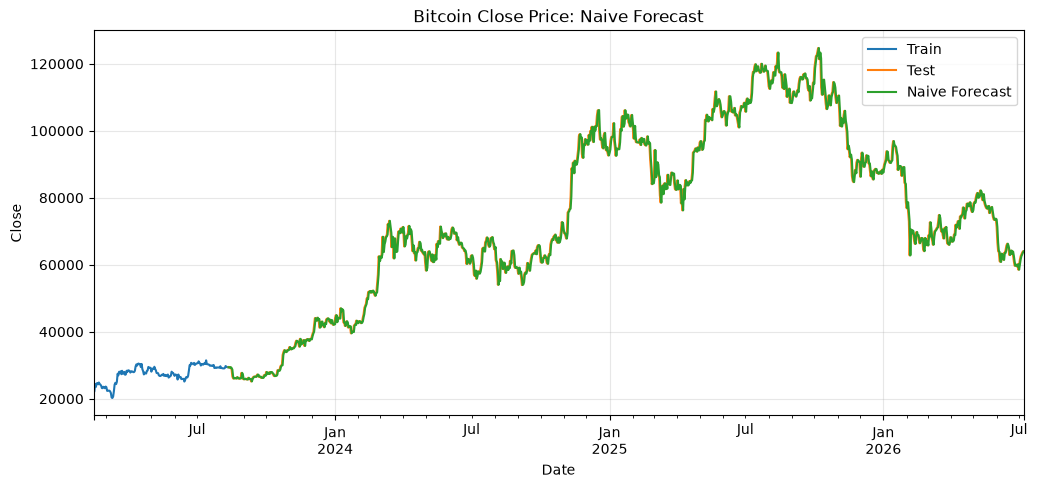

In [4]:
naive_forecast = target.shift(1).reindex(test.index).rename("Naive")

fig, ax = plt.subplots(figsize=(12, 5))
train.tail(180).plot(ax=ax, label="Train")
test.plot(ax=ax, label="Test")
naive_forecast.plot(ax=ax, label="Naive Forecast")
ax.set_title("Bitcoin Close Price: Naive Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 5. Moving Average Forecast

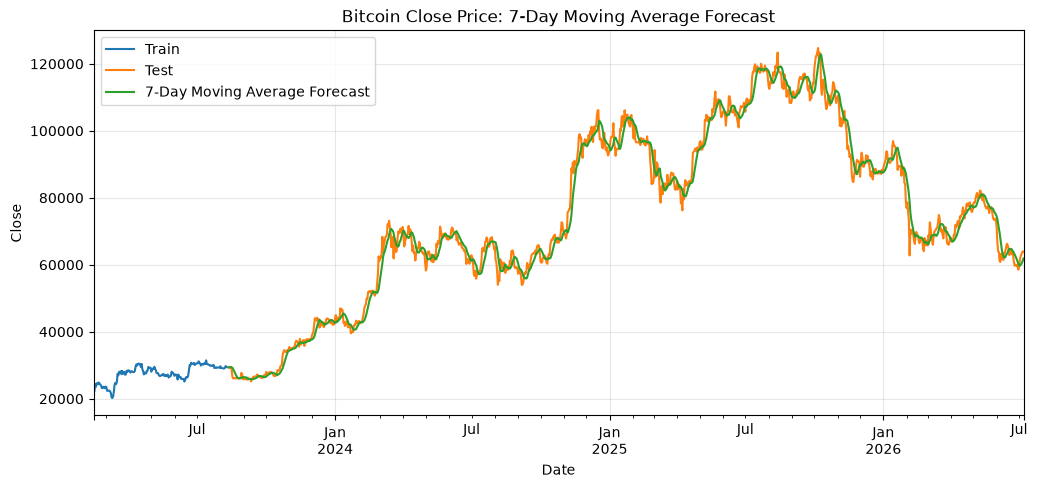

In [5]:
moving_average_forecast = (
    target.shift(1)
    .rolling(window=7)
    .mean()
    .reindex(test.index)
    .rename("7-Day Moving Average")
)

fig, ax = plt.subplots(figsize=(12, 5))
train.tail(180).plot(ax=ax, label="Train")
test.plot(ax=ax, label="Test")
moving_average_forecast.plot(ax=ax, label="7-Day Moving Average Forecast")
ax.set_title("Bitcoin Close Price: 7-Day Moving Average Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 6. Exponential Smoothing

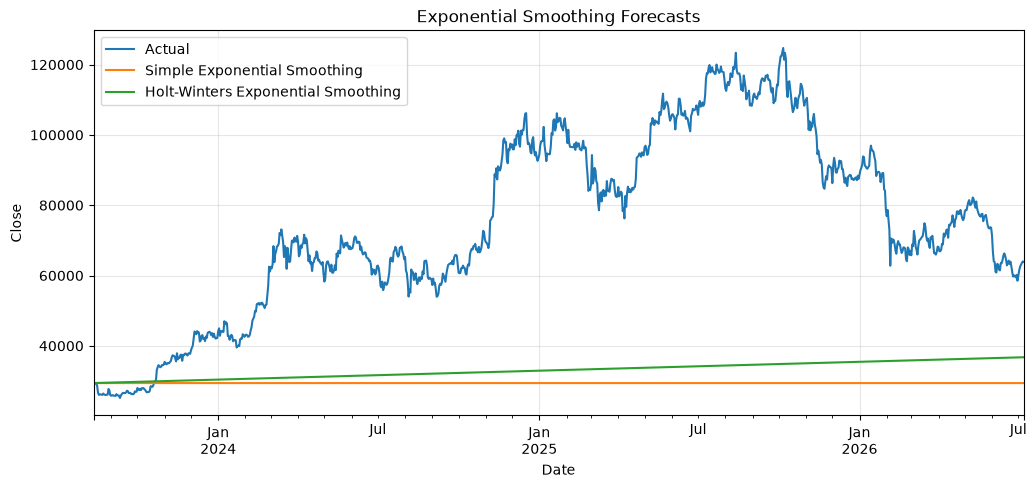

In [6]:
simple_exp_model = SimpleExpSmoothing(
    train,
    initialization_method="estimated",
).fit(optimized=True)
simple_exp_forecast = simple_exp_model.forecast(len(test)).rename("Simple Exponential Smoothing")
simple_exp_forecast.index = test.index

holt_winters_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None,
    initialization_method="estimated",
).fit(optimized=True)
holt_winters_forecast = holt_winters_model.forecast(len(test)).rename("Holt-Winters")
holt_winters_forecast.index = test.index

fig, ax = plt.subplots(figsize=(12, 5))
test.plot(ax=ax, label="Actual")
simple_exp_forecast.plot(ax=ax, label="Simple Exponential Smoothing")
holt_winters_forecast.plot(ax=ax, label="Holt-Winters Exponential Smoothing")
ax.set_title("Exponential Smoothing Forecasts")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 7. ARIMA

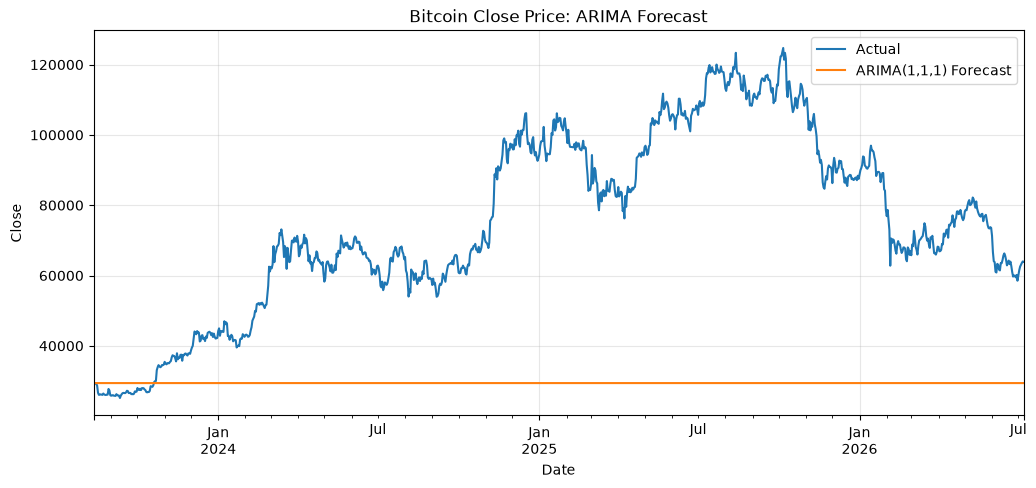

In [7]:
arima_order = (1, 1, 1)
arima_model = ARIMA(train, order=arima_order).fit()
arima_forecast = arima_model.forecast(steps=len(test)).rename("ARIMA(1,1,1)")
arima_forecast.index = test.index

fig, ax = plt.subplots(figsize=(12, 5))
test.plot(ax=ax, label="Actual")
arima_forecast.plot(ax=ax, label="ARIMA(1,1,1) Forecast")
ax.set_title("Bitcoin Close Price: ARIMA Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 8. Evaluation Metrics

In [8]:
def evaluate_forecast(y_true, y_pred):
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
    }


forecasts = {
    "Naive": naive_forecast,
    "7-Day Moving Average": moving_average_forecast,
    "Simple Exponential Smoothing": simple_exp_forecast,
    "Holt-Winters Exponential Smoothing": holt_winters_forecast,
    "ARIMA(1,1,1)": arima_forecast,
}

metrics_table = pd.DataFrame(
    [evaluate_forecast(test, forecast) for forecast in forecasts.values()],
    index=forecasts.keys(),
)

metrics_table

,MAE,RMSE,MAPE,sMAPE
Naive,1290.353242,1853.624774,1.742747,1.744142
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208
Simple Exponential Smoothing,46098.008850,52421.328707,55.428501,80.629328
Holt-Winters Exponential Smoothing,42453.125941,48571.096828,50.908777,71.495187
"ARIMA(1,1,1)",46098.348299,52421.667992,55.428923,80.630235


## 9. Model Comparison

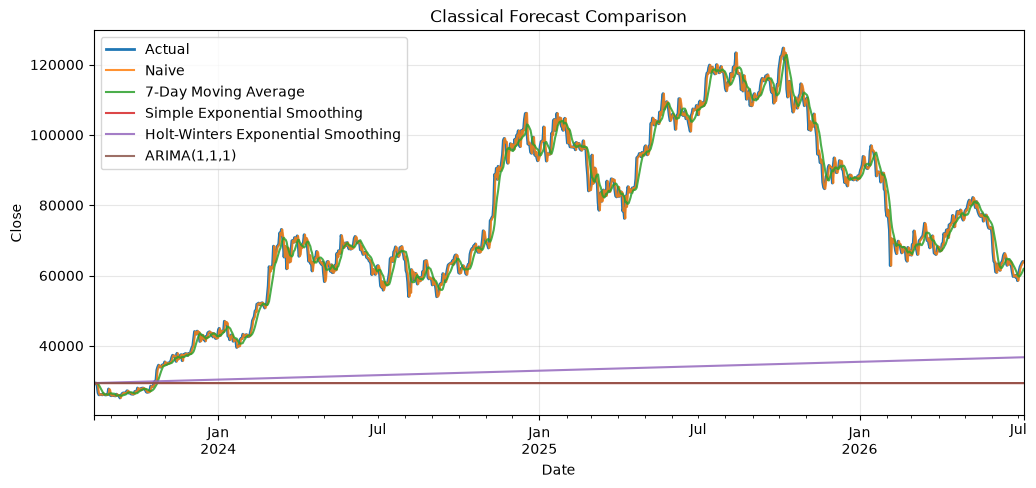

,MAE,RMSE,MAPE,sMAPE
Naive,1290.353242,1853.624774,1.742747,1.744142
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208
Holt-Winters Exponential Smoothing,42453.125941,48571.096828,50.908777,71.495187
Simple Exponential Smoothing,46098.008850,52421.328707,55.428501,80.629328
"ARIMA(1,1,1)",46098.348299,52421.667992,55.428923,80.630235


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
test.plot(ax=ax, label="Actual", linewidth=2)

for model_name, forecast in forecasts.items():
    forecast.plot(ax=ax, label=model_name, alpha=0.85)

ax.set_title("Classical Forecast Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

metrics_table.sort_values("RMSE")

## 10. Forecast Diagnostics

First 10 forecast diagnostics:
                            y_test    Naive  7-Day Moving Average  Simple Exponential Smoothing  Holt-Winters  ARIMA(1,1,1)
Timestamp                                                                                                                  
2023-08-12 00:00:00+00:00  29415.0  29398.0          29346.000000                  29399.069763  29406.252150  29398.729090
2023-08-13 00:00:00+00:00  29284.0  29415.0          29398.285714                  29399.069763  29413.175909  29398.677822
2023-08-14 00:00:00+00:00  29408.0  29284.0          29432.857143                  29399.069763  29420.099668  29398.681427
2023-08-15 00:00:00+00:00  29172.0  29408.0          29465.285714                  29399.069763  29427.023427  29398.681174
2023-08-16 00:00:00+00:00  28701.0  29172.0          29380.714286                  29399.069763  29433.947186  29398.681191
2023-08-17 00:00:00+00:00  26642.0  28701.0          29257.285714                  29399.069763  2944

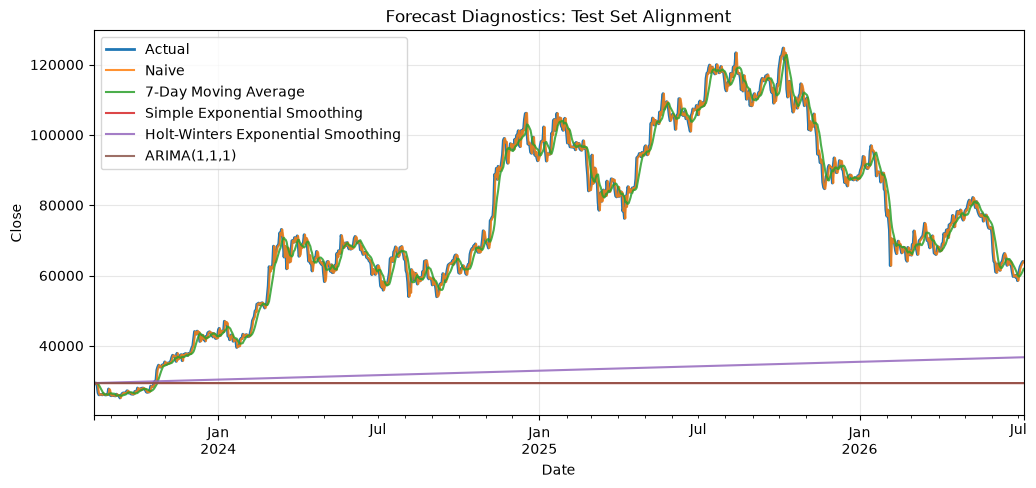

In [10]:
diagnostics = pd.DataFrame(
    {
        "y_test": y_test,
        "Naive": naive_forecast,
        "7-Day Moving Average": moving_average_forecast,
        "Simple Exponential Smoothing": simple_exp_forecast,
        "Holt-Winters": holt_winters_forecast,
        "ARIMA(1,1,1)": arima_forecast,
    }
)

print("First 10 forecast diagnostics:")
print(diagnostics.head(10).to_string())

print("Naive forecast equals one-step lagged actuals:")
print(naive_forecast.equals(target.shift(1).reindex(y_test.index)))

print("ARIMA forecast index aligns with y_test:")
print(arima_forecast.index.equals(y_test.index))

fig, ax = plt.subplots(figsize=(12, 5))
y_test.plot(ax=ax, label="Actual", linewidth=2)

for model_name, forecast in forecasts.items():
    forecast.plot(ax=ax, label=model_name, alpha=0.85)

ax.set_title("Forecast Diagnostics: Test Set Alignment")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

The naive forecast is now implemented as true one-step persistence by using the previous observed close for each test timestamp. The diagnostic check should return `True` when `naive_forecast` equals `target.shift(1).reindex(y_test.index)`. ARIMA forecasts are explicitly assigned the same index as `y_test`, so the index alignment check should also return `True`.

## 11. Key Findings

- The naive forecast provides a simple persistence baseline.
- The 7-day moving average forecast smooths recent price behavior and can be compared against the naive baseline using the metrics table.
- Simple Exponential Smoothing, Holt-Winters Exponential Smoothing, and ARIMA add classical statistical baselines for comparison.
- Lower MAE, RMSE, MAPE, and sMAPE values indicate stronger out-of-sample performance on the chronological test set.